## 1. Tải dữ liệu

In [1]:
import pandas as pd
df_train = pd.read_csv('../data/01_raw/train.csv')
df_test = pd.read_csv('../data/01_raw/test.csv')

## 2. Kiểm tra dữ liệu từ train

In [4]:
df_train.head()
df_train.info()
# Tạo DataFrame mô tả
df_train.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Nhận xét:

Một số cột thiếu dữ liệu: LotFrontage(kieu float) chỉ có 1201 giá trị, bị thiếu 259, GarageYrBlt (năm xây dựng) có 1379 giá trị, thiếu 81 giá trị, MasVnrArea(Diện tich ốp gạch) có 1452 giá trị, bị thiếu 8 giá trị. Một số cột phân phố bị lệch khi mean của SalePrice là 180921 lớn hơn trung vị 163000, cho thấy cột này đang bị lệch phải LotArea: mean (10,516) > median (9,478). Có một vài lô đất rất lớn. GrLivArea: mean (1515) > median (1464). Có một vài ngôi nhà diện tích rất lớn. MasVnrArea: mean (103) > median (0). Bị lệch nghiêm trọng, vì hầu hết các nhà có giá trị ở trung vị là 0. Nhiều cột có min, 25% và 50% (median) đều bằng 0. 2ndFlrSF: 50% là 0, có nghĩa là hơn một nửa số nhà trong tập dữ liệu này là nhà 1 tầng (không có lầu 2).PoolArea: mean rất nhỏ (2.7) và 50% là 0. Điều này cho thấy gần như không có nhà nào có hồ bơi.Các biến khác: WoodDeckSF, OpenPorchSF, EnclosedPorch, ScreenPorch, BsmtFinSF2, LowQualFinSF, MiscVal... đều có rất nhiều giá trị 0. Đây không phải là dữ liệu xấu. Nó có nghĩa là "0" là một giá trị hợp lệ, mang ý nghĩa là "không có" (không có hiên, không có hồ bơi, v.v.).

## 3. EDA

## Phân tích biến mục tiêu: SalePrice

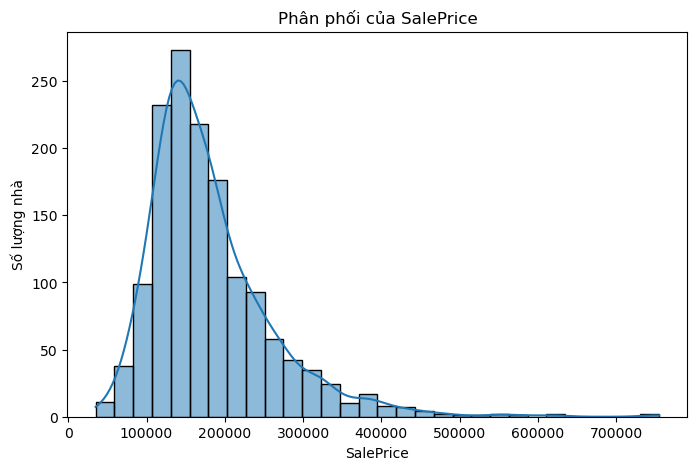

Skewness: 1.8828757597682129


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(df_train['SalePrice'], kde=True, bins=30)
plt.title("Phân phối của SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Số lượng nhà")
plt.show()

# Kiểm tra độ lệch
print("Skewness:", df_train['SalePrice'].skew())


Nhận xét:

Phân phối lệch phải, tập trung ở giá thấp đến trung bình với đỉnh là 150000 -180000 


## 2. Ma trận tương quan giữa các biến số

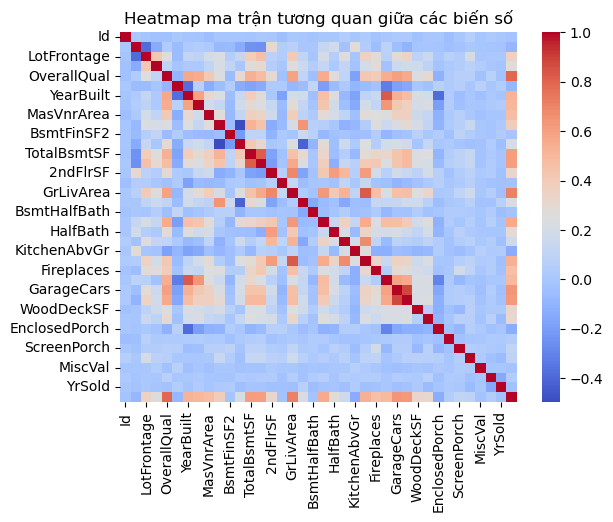

In [7]:
corr = df_train.corr(numeric_only=True)
plt.Figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Heatmap ma trận tương quan giữa các biến số")
plt.show()

Tìm những biến tương quan mạnh với SalePrice

In [8]:
# Lấy 10 cột tương quan cao nhất
top_corr = corr['SalePrice'].sort_values(ascending=False).head(10)
print(top_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


Nhận xét:

OverallQual (Chất lượng tổng thể): 0.79 Đây là đặc trưng quan trọng nhất! Nó có mối quan hệ tuyến tính mạnh nhất với giá bán. Chỉ riêng việc biết chất lượng tổng thể của ngôi nhà đã cho bạn một chỉ báo rất tốt về giá của nó.GrLivArea (Diện tích sống): 0.71. Đặc trưng quan trọng thứ hai. Rất logic, nhà càng rộng thì giá càng cao.GarageCars & GarageArea (Số chỗ đậu xe & Diện tích Garage): 0.64 & 0.62. Garage lớn (chứa được nhiều xe) là một yếu tố dự đoán giá rất tốt. (Hai biến này có thể bị tương quan cao với nhau, gọi là đa cộng tuyến).TotalBsmtSF & 1stFlrSF (Tổng diện tích tầng hầm & Tầng 1): 0.61 & 0.60. Tổng diện tích sử dụng (bao gồm cả tầng hầm) ảnh hưởng lớn đến giá trị. Các Đặc trưng Quan trọng (Tương quan > 0.5): FullBath (Số phòng tắm): 0.56
TotRmsAbvGrd (Tổng số phòng): 0.53. YearBuilt (Năm xây dựng): 0.52. Nhà càng mới (năm xây dựng càng lớn) thì giá càng cao.

## Phân tích biến phân loại (Categorical Variables) (Vẽ 1 vài biểu đồ có sự tương quan cao với SalePrice)

## Biểu đồ theo chất lượng tổng thể

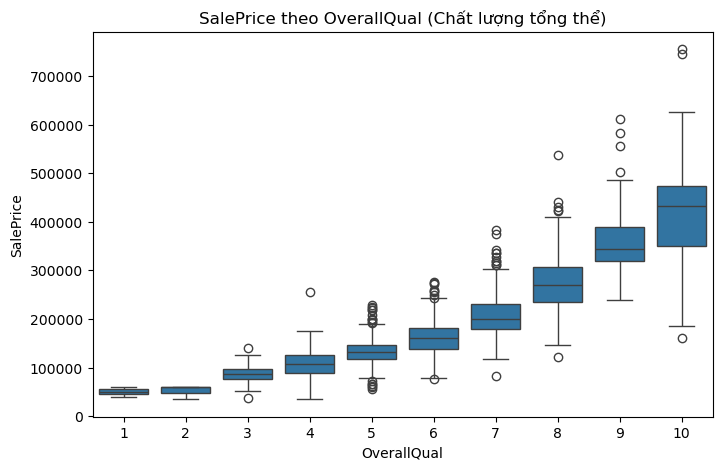

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train)
plt.title("SalePrice theo OverallQual (Chất lượng tổng thể)")
plt.show()

Nhận xét:

Nhà có chất lượng tổng thể (OverallQual) càng cao thì giá bán (SalePrice) càng cao. Điều này hoàn toàn khớp với chỉ số tương quan 0.79 mà bạn tìm thấy trước đó. Khi nhìn vào OverallQual từ 1-3 hộp rất dẹt cho thấy với chất lượng thấp này thì SalePrice khá tương đồng nhau. OverallQual từ 7-10 hộp khoảng giá khá rộng giá cả lúc này phân bố có giá chênh nhau nhiều. Nhìn vào outlier ở OverallQual thấp thì giá ổn định ít outlier so với cao   

## Biểu đồ theo khu vực

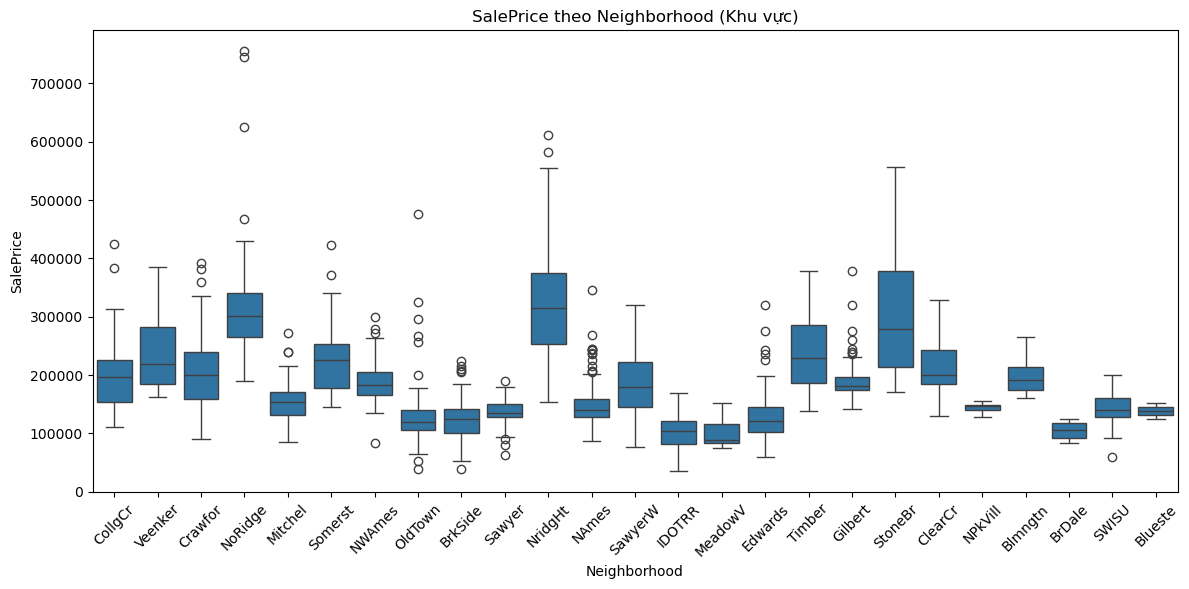

In [10]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df_train)
plt.xticks(rotation=45)
plt.title("SalePrice theo Neighborhood (Khu vực)")
plt.show()


Nhận xét:

Biểu đồ boxplot này cho thấy khu vực là một yếu tố dự đoán giá cực kỳ quan trọng. Có sự khác biệt rất lớn về giá nhà giữa các khu vực khác nhau. Rõ ràng, các khu như NridgHt, NoRidge, và StoneBr có mức giá trung vị (median) cao nhất, đây là những khu đắt đỏ. Ngược lại, các khu như MeadowV, IDOTRR, và BrDale có mức giá thấp và ổn định nhất (hộp rất "dẹt"). Biểu đồ cũng cho thấy sự biến động giá (chiều cao của hộp) rất khác nhau; một số khu có giá rất đa dạng (như NridgHt), trong khi khu khác thì giá lại rất đồng đều (như BrDale). Biến này chắc chắn phải được đưa vào mô hình.

## Biểu đồ hộp theo “BsmtQual” (Chất lượng tầng hầm)

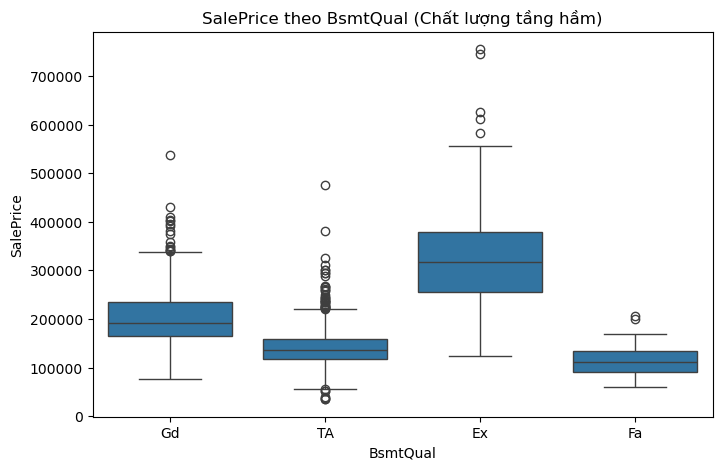

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='BsmtQual', y='SalePrice', data=df_train)
plt.title("SalePrice theo BsmtQual (Chất lượng tầng hầm)")
plt.show()


Nhận xét:

Biểu đồ boxplot này cho thấy BsmtQual (Chất lượng tầng hầm) có mối quan hệ thứ tự (ordinal) rất rõ ràng với SalePrice. Khi chất lượng tăng lên theo thứ tự Fa (Fair/Tạm) $\rightarrow$ TA (Typical/Trung bình) $\rightarrow$ Gd (Good/Tốt) $\rightarrow$ Ex (Excellent/Xuất sắc), giá bán trung vị (đường kẻ ngang trong hộp) cũng tăng lên một cách rõ rệt.  Phân loại Ex (Xuất sắc) có giá nhà trung vị cao nhất và cũng có khoảng giá (chiều cao hộp) rộng nhất, cho thấy sự đa dạng về giá ở phân khúc cao cấp. Ngược lại, Fa có mức giá thấp và ổn định nhất. Điều này khẳng định đây là một biến phân loại có thứ tự quan trọng, và khi xử lý, nên mã hóa nó theo đúng thứ tự (ví dụ: Fa=1, TA=2, Gd=3, Ex=4) thay vì dùng one-hot.
